# M6 — Option valuation through replication

An option’s payoff describes what it pays at expiry; valuation asks what that future payoff is worth today. We start with a simplified market where a combination of an asset and borrowing can reproduce the option’s payoff in every modeled outcome. The cost of that combination provides a model price.

Read [M5](M5_calls_and_puts.ipynb) and Notebook 2 first. This lesson uses a **hypothetical tradable asset**, not actual computer time. One unit costs USD 5 today. In one year it will be worth either 1.2 times or 0.8 times that amount.

A call option pays any amount above a USD 5 strike at that year's end. Money saved or borrowed grows at 5% over the year. Assume no trading costs or payouts from the asset, and the same rate for saving and borrowing. Also allow selling borrowed assets, called **short selling**.

These are model rules, not facts about compute markets. Computer service for a particular date cannot simply be stored for another date. We do not claim one model unit equals a GPU-hour, and we do not replace M5's assumed premium with this price.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.option_valuation import (
    binomial_european_option_tree,
    one_step_replication,
)

model = dict(
    kind="call",
    spot_usd_per_unit=5.0,
    strike_usd_per_unit=5.0,
    up_factor=1.2,
    down_factor=0.8,
    effective_annual_rate=0.05,
    step_years=1.0,
)
print("One normalized proxy unit; one-year steps; effective annual rate 5%.")

One normalized proxy unit; one-year steps; effective annual rate 5%.


## Establish the option’s possible payoffs

If the asset goes up, it becomes **USD 5 × 1.2 = USD 6**. The call pays **USD 1**, the amount above its USD 5 strike.

If the asset goes down, it becomes **USD 5 × 0.8 = USD 4**. The call pays **zero**.

Knowing those payments does not yet tell us today's price. First, construct a position that pays exactly USD 1 in the up case and zero in the down case.

In [3]:
spot = model["spot_usd_per_unit"]
strike = model["strike_usd_per_unit"]
up_price = spot * model["up_factor"]
down_price = spot * model["down_factor"]
up_payoff = max(up_price - strike, 0)
down_payoff = max(down_price - strike, 0)
show_finance_table(
    ["State", "Proxy price USD/unit", "Call payoff USD"],
    [
        ["Down", down_price, down_payoff],
        ["Up", up_price, up_payoff],
    ],
)

| State | Proxy price USD/unit | Call payoff USD |
| --- | --- | --- |
| Down | 4.00 | 0.00 |
| Up | 6.00 | 1.00 |

## Build a replicating portfolio

Buy **half a unit** of the asset for USD 2.50. Borrow **USD 1.9047619**. After one year, that borrowing grows to **USD 2** at 5%.

If the asset rises to USD 6, our half is worth USD 3. Repay USD 2 and keep **USD 1**.

If it falls to USD 4, our half is worth USD 2. Repay USD 2 and keep **zero**.

This exactly matches the call. The combined position costs **USD 2.50 − USD 1.9047619 = USD 0.5952381** today. Under our trading rules, that is the model's call price.

Holding assets and borrowing that reproduce the option’s payoffs is called **replication**. The combined position is its **replicating portfolio**. [Andrew Lo's MIT lectures, slides 16–21](https://ocw.mit.edu/courses/15-401-finance-theory-i-fall-2008/c40ecc0cc0dce0fbf2d229bc4027c43b_MIT15_401F08_lec10.pdf) explain the method. Our 5% annual rate gives a growth factor of 1.05; a growth factor is not itself a percentage.

In [4]:
growth = (1 + model["effective_annual_rate"]) ** model["step_years"]
delta = (up_payoff - down_payoff) / (up_price - down_price)
cash = (down_payoff - delta * down_price) / growth
value = delta * spot + cash
pricing_weight = (growth - model["down_factor"]) / (
    model["up_factor"] - model["down_factor"]
)
show_finance_table(
    ["Direct calculation", "Value"],
    [
        ["Delta units", delta],
        ["Initial cash USD", cash],
        ["Initial value USD", value],
        ["Down portfolio USD", delta * down_price + cash * growth],
        ["Up portfolio USD", delta * up_price + cash * growth],
        ["Pricing up weight", pricing_weight],
    ],
)
print(f"Replicating value: USD {value:.7f}; pricing weight: {pricing_weight:.3f}")

| Direct calculation | Value |
| --- | --- |
| Delta units | 0.50 |
| Initial cash USD | -1.90 |
| Initial value USD | 0.60 |
| Down portfolio USD | 0.00 |
| Up portfolio USD | 1.00 |
| Pricing up weight | 0.63 |

Replicating value: USD 0.5952381; pricing weight: 0.625


The replicating portfolio pays zero or USD 1, matching the option in both outcomes.

A shortcut gives the same price: put weight **0.625** on the USD 1 payoff, then divide by 1.05. The result is **USD 0.5952381**. This **pricing weight** comes from the matching calculation. It is not a claim that the price has a 62.5% chance of rising.

Now repeat the up/down rules for **two one-year steps**. The option ends in two years, not one. Final asset prices are USD 3.20, USD 4.80 and USD 7.20; call payments are zero, zero and USD 2.20. Working backward gives **USD 0.7794785** today.

The branching chart shows possible asset prices. Optional controls change the one-year model and reject rules that do not fit together. Editable cells are also available.

| Contract | Value USD/unit | Expiry years |
| --- | --- | --- |
| One step | 0.60 | 1.00 |
| Two steps | 0.78 | 2.00 |

Two-year call value: USD 0.7794785


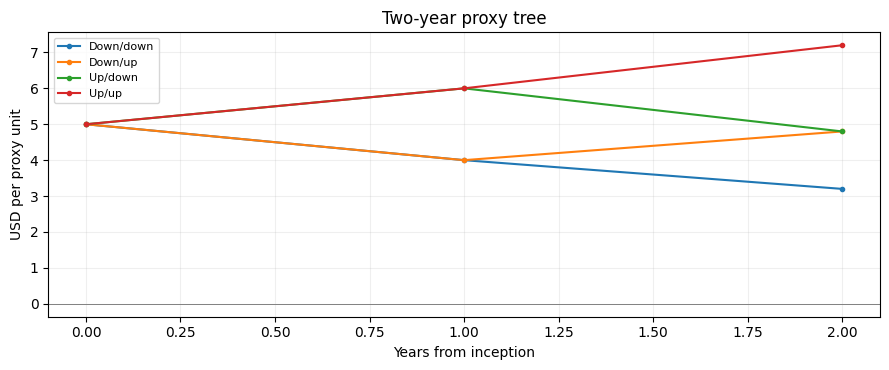

In [5]:
replication = one_step_replication(**model)
two_year = binomial_european_option_tree(**model, steps=2)
show_finance_table(
    ["Contract", "Value USD/unit", "Expiry years"],
    [
        ["One step", replication.value_usd, 1],
        ["Two steps", two_year.option_values_usd[0][0], 2],
    ],
)
print(f"Two-year call value: USD {two_year.option_values_usd[0][0]:.7f}")
p = two_year.prices_usd_per_unit
display(
    plot_finance_series(
        {
            "Down/down": [p[0][0], p[1][0], p[2][0]],
            "Down/up": [p[0][0], p[1][0], p[2][1]],
            "Up/down": [p[0][0], p[1][1], p[2][1]],
            "Up/up": [p[0][0], p[1][1], p[2][2]],
        },
        title="Two-year proxy tree",
        xlabel="Years from inception",
        ylabel="USD per proxy unit",
        x_values=(0, 1, 2),
    )
)


def tree_explorer(values, baseline=model.copy()):
    from liquid_compute.option_valuation import one_step_replication

    changed = baseline | {
        "up_factor": values["Up factor"],
        "down_factor": values["Down factor"],
        "effective_annual_rate": values["Annual rate fraction"],
    }
    result = one_step_replication(**changed)
    return {
        f"Down branch; option PV {result.value_usd:.7f} USD/unit": [
            baseline["spot_usd_per_unit"],
            result.down_price_usd,
        ],
        "Up branch": [baseline["spot_usd_per_unit"], result.up_price_usd],
    }


explore_finance_series(
    {"Up factor": 1.2, "Down factor": 0.8, "Annual rate fraction": 0.05},
    tree_explorer,
    title="One-year proxy branches",
    ylabel="USD per proxy unit",
    xlabel="Years from inception",
    x_values=(0, 1),
);

The two-year price applies to a different end date. Keep that difference in mind when comparing it with the one-year result.

## Experiment 1 — Change the forecast probabilities

Suppose a planner believes the up case has a 25% chance, then a 75% chance. Their average expected option payment changes from **USD 0.25 to USD 0.75**.

Dividing either average by 1.05 gives a value based on that belief. It does not establish the replication price.

The asset prices, option payments and borrowing rate have not changed. The replicating portfolio and its cost therefore stay the same. Business probabilities and model pricing weights answer different questions.

In [6]:
forecast_probabilities = (0.25, 0.75)
show_finance_table(
    [
        "Business up probability",
        "Expected payoff USD",
        "Expectation / growth USD",
        "Replicating value USD",
    ],
    [
        [
            prob,
            prob * up_payoff + (1 - prob) * down_payoff,
            (prob * up_payoff + (1 - prob) * down_payoff) / growth,
            replication.value_usd,
        ]
        for prob in forecast_probabilities
    ],
)

| Business up probability | Expected payoff USD | Expectation / growth USD | Replicating value USD |
| --- | --- | --- | --- |
| 0.25 | 0.25 | 0.24 | 0.60 |
| 0.75 | 0.75 | 0.71 | 0.60 |

The discounted belief-based averages are **USD 0.2380952 and USD 0.7142857**. The replication price remains **USD 0.5952381**.

Changing the forecast probabilities alone does not change the cost or payoffs of the replicating portfolio.

## Experiment 2 — Bigger possible price moves

Keep the one-year end date, strike and rate. Change the up/down factors to **1.4 and 0.6**. Final prices are now USD 7 and USD 3, so the call pays USD 2 or zero.

We have widened the model's possible outcomes. We have not measured real market volatility or changed the option strike.

In [7]:
wider = one_step_replication(**(model | {"up_factor": 1.4, "down_factor": 0.6}))
show_finance_table(
    ["Case", "Down price", "Up price", "Pricing up weight", "Value USD/unit"],
    [
        [
            "Base",
            replication.down_price_usd,
            replication.up_price_usd,
            replication.pricing_up_weight,
            replication.value_usd,
        ],
        [
            "Wider states",
            wider.down_price_usd,
            wider.up_price_usd,
            wider.pricing_up_weight,
            wider.value_usd,
        ],
    ],
)

| Case | Down price | Up price | Pricing up weight | Value USD/unit |
| --- | --- | --- | --- | --- |
| Base | 4.00 | 6.00 | 0.63 | 0.60 |
| Wider states | 3.00 | 7.00 | 0.56 | 1.07 |

The model call price rises to **USD 1.0714286**. The pricing weight becomes **0.5625**.

The larger rise can pay the call holder more, while its payoff in the down case is still zero. Both comparisons use the same one-year end date.

## Experiment 3 — Identify inconsistent model assumptions

Set the down/up factors to 0.9 and 1.02 while saved money grows by 1.05. Now saving grows faster than even the asset's best outcome. With free short selling, the model would allow a sure gain with no initial investment: sell a borrowed asset, save the proceeds and buy it back later.

That opportunity for a risk-free gain is inconsistent with the model’s pricing assumptions. Savings growth must lie strictly between the down and up factors. The helper explains the problem instead of forcing the pricing weight into range and printing a misleading price.

In [8]:
try:
    one_step_replication(**(model | {"down_factor": 0.9, "up_factor": 1.02}))
except ValueError as error:
    print(f"No model price for these assumptions: {error}")

No model price for these assumptions: no-arbitrage requires down_factor < growth < up_factor


No valid price is produced for those inconsistent rules. That differs from a valid option that happens to pay zero. Identical up and down branches are also outside this two-outcome model.

When comparing the calculated prices, keep their end dates visible. Do not automatically replace M5's premium input.

Even a valid model leaves out trading costs and the risk that a real hedge tracks a different price. Most importantly, we would need evidence that the assumed asset can actually be bought, sold and borrowed as the model requires.

In [9]:
show_finance_table(
    ["Model case", "Expiry years", "Conditional value USD/unit"],
    [
        ["Base", 1, replication.value_usd],
        ["Wider states", 1, wider.value_usd],
        ["Two annual steps", 2, two_year.option_values_usd[0][0]],
    ],
)

| Model case | Expiry years | Conditional value USD/unit |
| --- | --- | --- |
| Base | 1.00 | 0.60 |
| Wider states | 1.00 | 1.07 |
| Two annual steps | 2.00 | 0.78 |

## Next — Funding a hedge before its final settlement

Continue to **M7: Hedge collateral and liquidity**. E1 later offers an optional extension with a second protection decision; it reuses this model.

These are prices under stated model rules, not offers someone will trade. We have not estimated real-world probabilities, fitted historical data or added early exercise. The model gives no ownership of GPUs. Using it for a real compute hedge would need separate evidence about what can be traded.